## Import modules and data

In [15]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from stockFunctions import stationarity_report, decompose_series, rmse_mape

warnings.filterwarnings("ignore")


In [16]:
df = pd.read_csv(r'D:\HopeAI\Assignments\12. Time_Series\3.TS-Models\Adanient-data.csv',
                  parse_dates=True, index_col="Date")
close = df["Close"].to_frame()

df


,Close,High,Low,Open,Volume
Date,,,,,
2021-01-01,489.959869,492.054787,475.844163,475.844163,5035248
2021-01-04,493.301758,501.382136,485.470773,490.807816,4936582
2021-01-05,493.201965,500.185003,488.413609,490.807787,3654033
2021-01-06,489.710480,499.436854,483.076600,494.798128,3295461
2021-01-07,516.844482,522.680343,492.603380,492.703144,9879731
...,...,...,...,...,...
2025-11-24,2399.199951,2432.300049,2393.100098,2426.199951,691419
2025-11-25,2332.899902,2407.699951,2325.300049,2400.899902,2223715
2025-11-26,2315.000000,2357.000000,2310.000000,2321.199951,1026965


## Stationarity Check

In [17]:
stationarity_report(df['Close'], "Raw Close")
stationarity_report(df['Close'].diff().dropna(), "Diff Close")
stationarity_report(np.log(df['Close']).diff().dropna(), "Log-Return")



Raw Close
ADF p-value: 0.083587898158766 - Non-stationary
KPSS p-value: 0.01 - Non-stationary
KS p-value: 9.220332871003991e-131 - Regime shift

Diff Close
ADF p-value: 0.0 - Stationary
KPSS p-value: 0.1 - Stationary
KS p-value: 0.01951436361806993 - Regime shift

Log-Return
ADF p-value: 6.813649538257421e-10 - Stationary
KPSS p-value: 0.046157830572510584 - Non-stationary
KS p-value: 0.00030350854569711545 - Regime shift


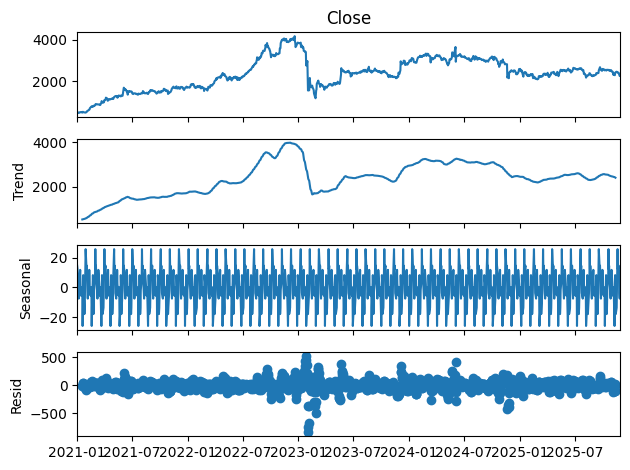

In [18]:
decompose_series(df["Close"], freq=22)


## Log and diff transforming data and splitting

In [19]:

y = np.log(df['Close']).diff().dropna()
train_size = int(len(y)*0.90)
train_y = y.iloc[:train_size]
test_y  = y.iloc[train_size:]


In [20]:

# Invert log differenced values
def invert_logdiff(base_price, diffs):
    prices = []
    last = base_price
    for d in diffs:
        last = last * np.exp(d)
        prices.append(last)
    return np.array(prices)


## All ARIMA and SARIMA models

In [21]:
# Hyperparameter Grid

trend_opts = ['c','ct']   # for AR, MA, ARMA
trend_none = ['n']       # for ARIMA, SARIMA

model_configs = [
    ('AR', range(0,4), trend_opts),
    ('MA', [(0, 0, q) for q in range(0,4)], trend_opts),
    ('ARMA', [(p, 0, q) for p in range(0,4) for q in range(0,4)], trend_opts),
    ('ARIMA', [(p, d, q) for p in range(0,4) for d in [1] for q in range(0,4)], trend_none), 
    ('SARIMA', [(p, d, q) for p in range(0,4) for d in [1] for q in range(0,4)], trend_none),
]


In [22]:
# Model Evaluation Function
def model_evaluation(model_name, train_y, test_y, orders, trends):
    results = []
    seasonal = None
    for order in orders:
        for trend in trends:
            try:
                if model_name == 'AR':
                    model = AutoReg(train_y, lags=order,trend= trend).fit()
                elif model_name == 'SARIMA':
                    for seasonal in [(1,1,1,12), (0,1,1,12)]:
                        model = SARIMAX(train_y, order=order,
                                        seasonal_order=seasonal,
                                        trend=trend,
                                        enforce_stationarity=False,
                                        enforce_invertibility=False).fit(disp=False)
                else:
                    model = ARIMA(train_y, order=order, trend=trend).fit()

                start = len(train_y)-1
                end   = start + len(test_y) - 1
                pred_y = model.predict(start=start, end=end)
                base = df['Close'].iloc[train_size]
                pred = invert_logdiff(base, pred_y)
                test = df['Close'].iloc[train_size+1:train_size+1+len(pred)]

                rmse, mape = rmse_mape(test, pred)
                results.append({"model": model_name,
                                "order": order,
                                "trend": trend,
                                "seasonal": seasonal,
                                "rmse": rmse,
                                "mape": mape,
                                "fit_obj": model
                            })
                results_df = pd.DataFrame(results)

            except Exception as exp:
                print('Exception Occurred', exp)
    return results_df.sort_values(["rmse", "mape"])


In [23]:
# Forecasting and Visualization
def finalize_and_plot(best_model_row, df, train_y, test_y):
    start = len(train_y)-1
    end   = start + len(test_y) - 1

    model_fit = best_model_row['fit_obj']

    pred_test = model_fit.predict(start=start, end=end)
    future_steps = 10
    forecast_logdiff = model_fit.forecast(steps=future_steps)
    base_test = df['Close'].iloc[train_size]
    test_prices = invert_logdiff(base_test, pred_test)

    base_future = df['Close'].iloc[-2]
    future_prices = invert_logdiff(base_future, forecast_logdiff)

    test_index = df.index[train_size+1:train_size+1+len(test_prices)]
    future_index = pd.date_range(
        start=df.index[-2] + pd.Timedelta(days=1),
        periods=10,
        freq='B'   
        )

    import matplotlib.pyplot as plt
    plt.style.use('default')
    plt.figure(figsize=(14,5))
    actual_test = df['Close'].iloc[train_size+1:train_size+1+len(test_prices)]
    plt.plot(test_index, actual_test, label="Actual")
    plt.plot(test_index, test_prices, label="Predicted", linestyle="--", color='green')
    plt.plot(future_index, future_prices, label=f"{future_steps}-Day Forecast", marker="o", color='red')

    plt.legend()
    plt.title("Price Forecast")
    plt.show()


Best Model in AR:
 model             AR
order              0
trend              c
seasonal        None
rmse        355.9067
mape           0.123
Name: 0, dtype: object


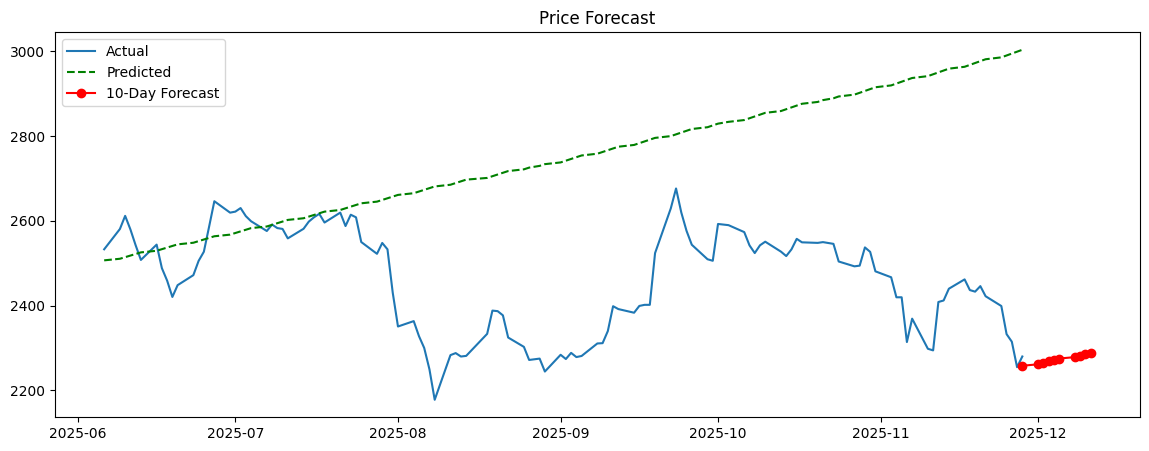

Best Model in MA:
 model              MA
order       (0, 0, 0)
trend               c
seasonal         None
rmse         354.9422
mape           0.1226
Name: 0, dtype: object


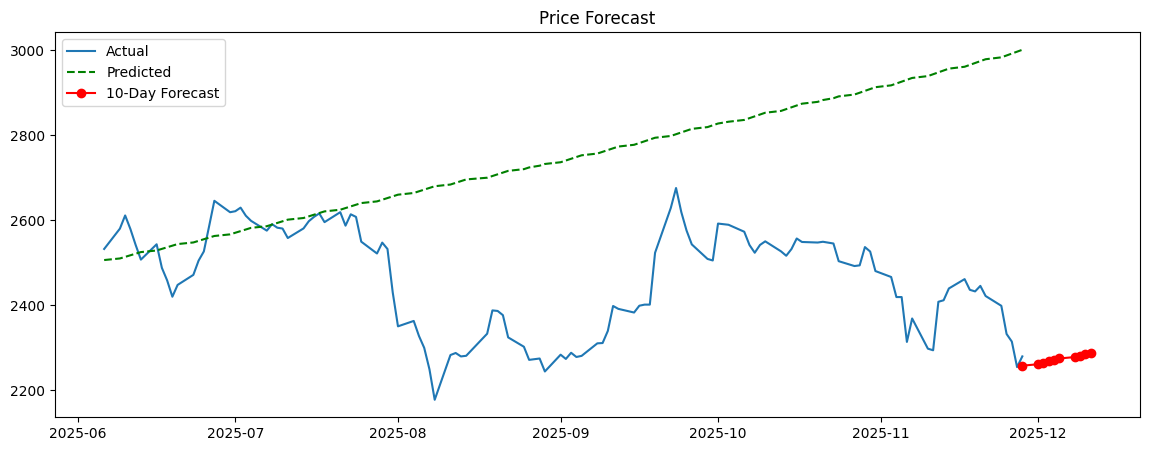

Best Model in ARMA:
 model            ARMA
order       (0, 0, 0)
trend               c
seasonal         None
rmse         354.9422
mape           0.1226
Name: 0, dtype: object


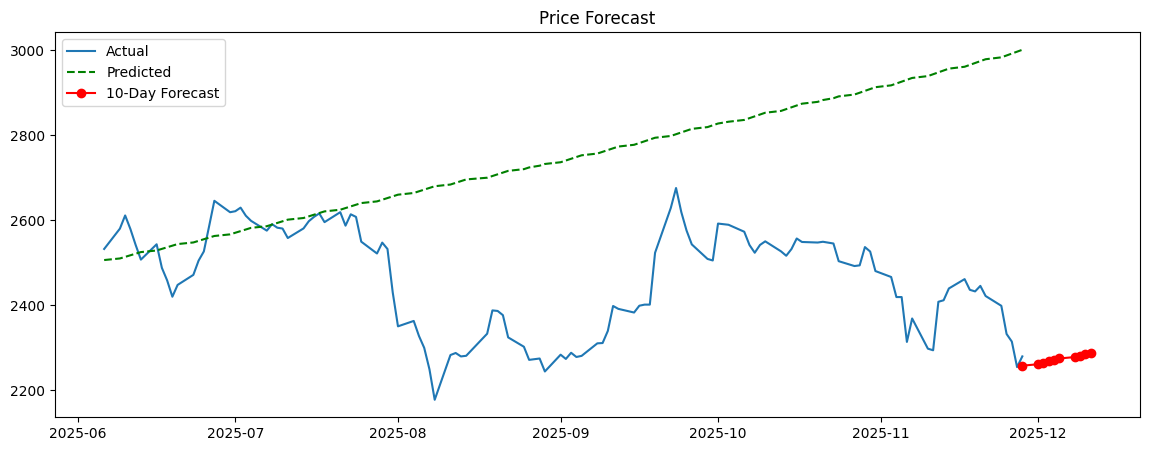

Exception Occurred Schur decomposition solver error.
Best Model in ARIMA:
 model           ARIMA
order       (3, 1, 3)
trend               n
seasonal         None
rmse         119.2493
mape           0.0419
Name: 14, dtype: object


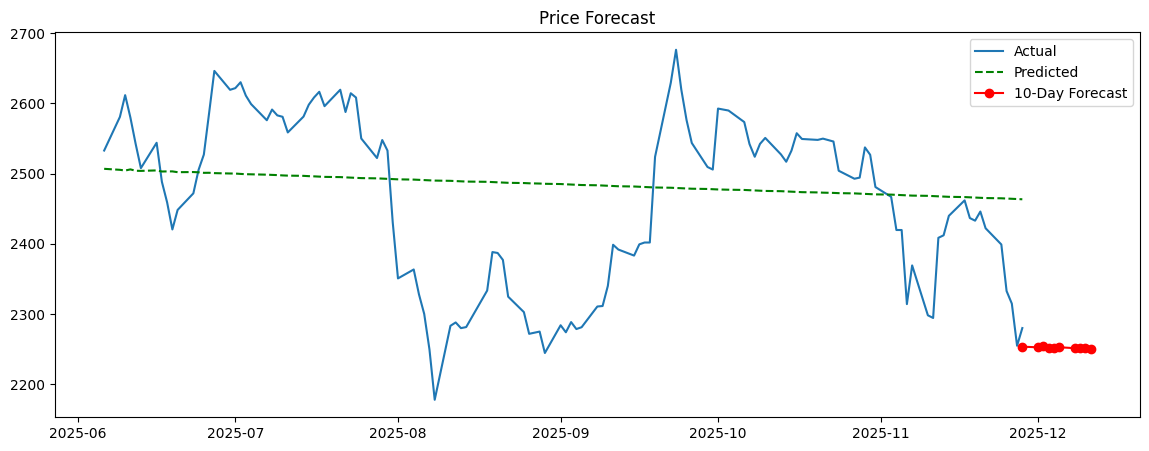

Best Model in SARIMA:
 model              SARIMA
order           (3, 1, 0)
trend                   n
seasonal    (0, 1, 1, 12)
rmse             187.0722
mape               0.0623
Name: 12, dtype: object


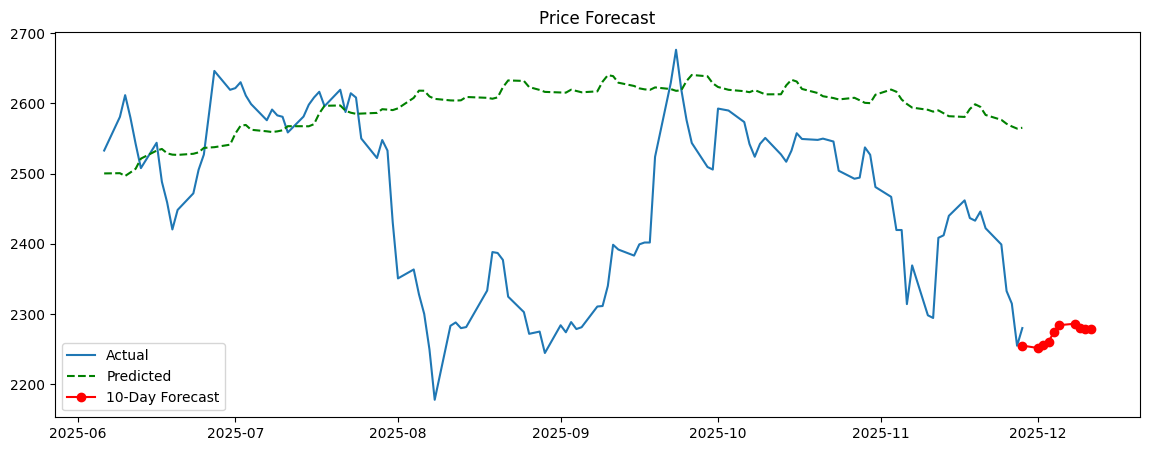

In [24]:
# Evaluate all models 
final_results = []
for name, orders, trends in model_configs:
    result = model_evaluation(name, train_y, test_y, orders, trends)
    best = result.iloc[0] if not result.empty else None
    print(f"Best Model in {name}:\n", best.iloc[:-1])
    finalize_and_plot(best, df, train_y, test_y)
    final_results.append(best)


## VAR Model

In [25]:
from itertools import combinations
from statsmodels.tsa.api import VAR

df_logdif = np.log(df).diff().dropna()

train_size = int(len(df_logdif) * 0.8)

results = []
target = 'Close'

for cols in combinations(df_logdif.columns, 3):

    if target not in cols:
        continue

    train_Z = df_logdif[list(cols)].iloc[:train_size]
    test_Z  = df_logdif[list(cols)].iloc[train_size:]

    for max_lag in range(1,8):
        model = VAR(train_Z).fit(maxlags=max_lag, ic='aic')
        lag = model.k_ar

        pred_Z = model.forecast(train_Z.values[-lag:], steps=len(test_Z))

        base = df['Close'].iloc[train_size]
        pred = invert_logdiff(base, pred_Z[:, list(cols).index(target)])
        test = df['Close'].iloc[train_size+1:train_size+1+len(pred)]

        rmse, mape = rmse_mape(test, pred)

        results.append({"model": 'VAR',
                                "order": lag,
                                "trend": cols,
                                "seasonal": None,
                                "rmse": rmse,
                                "mape": mape,
                                "fit_obj": model
                            })
results_df = pd.DataFrame(results).sort_values(["rmse", "mape"])
best = results_df.iloc[0]
print('\nBest VAR Model:\n', best.iloc[:-1])
final_results.append(best)



Best VAR Model:
 model                         VAR
order                           7
trend       (Close, High, Volume)
seasonal                     None
rmse                     664.5271
mape                       0.2432
Name: 20, dtype: object


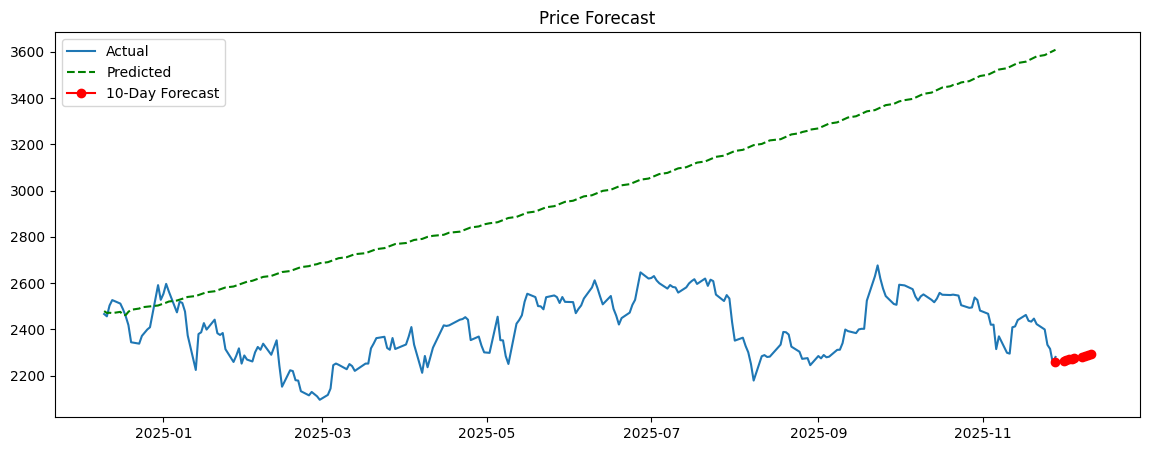

In [26]:
model = best['fit_obj']
cols = best['trend']
lag = model.k_ar

train_y = df_logdif[list(cols)].iloc[:train_size]
test_y  = df_logdif[list(cols)].iloc[train_size:]

y_last = train_y.values[-lag:]
future_steps = 10
# Test forecast
pred_all = model.forecast(y_last, steps=len(test_y))

# Future forecast
future_seed = np.vstack([y_last, pred_all])[-lag:]
forecast_all = model.forecast(future_seed, steps=future_steps)

# Extract Close only
target_idx = list(cols).index('Close')
pred_test = pred_all[:, target_idx]
forecast_logdiff = forecast_all[:, target_idx]

base_test = df['Close'].iloc[train_size]
test_prices = invert_logdiff(base_test, pred_test)

base_future = df['Close'].iloc[-2]
future_prices = invert_logdiff(base_future, forecast_logdiff)

test_index = df.index[train_size+1:train_size+1+len(test_prices)]
future_index = pd.date_range(
    start=df.index[-2] + pd.Timedelta(days=1),
    periods=10,
    freq='B'   
    )

import matplotlib.pyplot as plt
plt.style.use('default')
plt.figure(figsize=(14,5))
actual_test = df['Close'].iloc[train_size+1:train_size+1+len(test_prices)]
plt.plot(test_index, actual_test, label="Actual")
plt.plot(test_index, test_prices, label="Predicted", linestyle="--", color='green')
plt.plot(future_index, future_prices, label=f"{future_steps}-Day Forecast", marker="o", color='red')

plt.legend()
plt.title("Price Forecast")
plt.show()


## SES Model

In [27]:
# Raw data for SES and HWES
train_size = int(len(df)*0.80)
train = df.iloc[:train_size]
test  = df.iloc[train_size:]


In [28]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import numpy as np

ses_results = []

for alpha in np.linspace(0.1, 0.9, 9):
    try:
        model = SimpleExpSmoothing(train['Close']).fit(
            smoothing_level=alpha,
            optimized=False
        )
        pred = model.forecast(len(test))
        rmse, mape = rmse_mape(test['Close'], pred)
        results.append({"model": 'SES',
                        "order": alpha,
                        "trend": None,
                        "seasonal": None,
                        "rmse": rmse,
                        "mape": mape,
                        "fit_obj": model
                    })
    except:
        pass
results_df = pd.DataFrame(results).sort_values(["rmse", "mape"])
best = results_df.iloc[0] 
print("Best SES:", best[:-1])
final_results.append(best)


Best SES: model            SES
order            0.2
trend           None
seasonal        None
rmse        149.6902
mape          0.0524
Name: 43, dtype: object


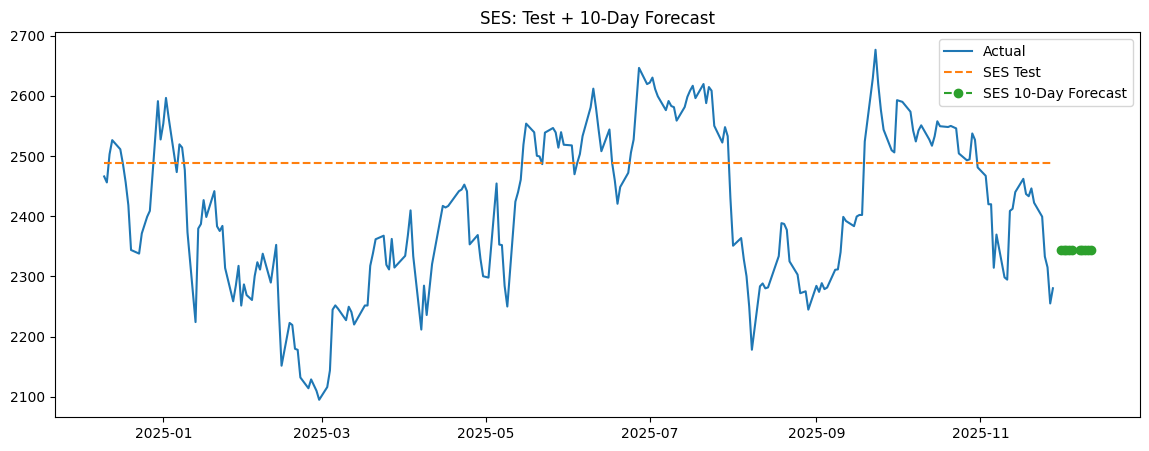

In [29]:
# Refit best SES
ses_best = SimpleExpSmoothing(train['Close']).fit(
    smoothing_level=best['order'],
    optimized=False
)
ses_pred = ses_best.forecast(len(test))

# Refit SES on full data
ses_final = SimpleExpSmoothing(df['Close']).fit(
    smoothing_level=best['order'],
    optimized=False
)

future_steps = 10

ses_future = ses_final.forecast(future_steps)

future_index = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq='B'
)

plt.figure(figsize=(14,5))

# Actual
plt.plot(test.index, test['Close'], label="Actual")

# Test predictions
plt.plot(test.index, ses_pred, '--', label="SES Test")

# Future forecasts
plt.plot(future_index, ses_future, 'o--', label="SES 10-Day Forecast")

plt.legend()
plt.title("SES: Test + 10-Day Forecast")
plt.show()


## HWES Model

In [30]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from itertools import product

hw_results = []

trends = [None, 'add', 'mul']
seasonals = [None, 'add', 'mul']
periods = [5, 7, 12, 22]
damped = [True, False]

for t, s, p, d in product(trends, seasonals, periods, damped):
    if s is None and p is not None:
        continue
    try:
        model = ExponentialSmoothing(
            train['Close'],
            trend=t,
            seasonal=s,
            seasonal_periods=p if s else None,
            damped_trend=d
        ).fit(optimized=True)
        
        pred = model.forecast(len(test))
        rmse, mape = rmse_mape(test['Close'], pred)
        # hw_results.append([t, s, p, d, rmse, mape])
        results.append({"model": 'HWES',
                        "order": p,
                        "trend": str(t)+", "+str(d),
                        "seasonal": s,
                        "rmse": rmse,
                        "mape": mape,
                        "fit_obj": model
                    })
    except:
        pass

results_df = pd.DataFrame(results).sort_values(["rmse", "mape"])
best = results_df.iloc[0] 
print("Best HWES:", best[:-1])
final_results.append(best)


Best HWES: model             HWES
order             22.0
trend       mul, False
seasonal           mul
rmse          139.5485
mape             0.049
Name: 90, dtype: object


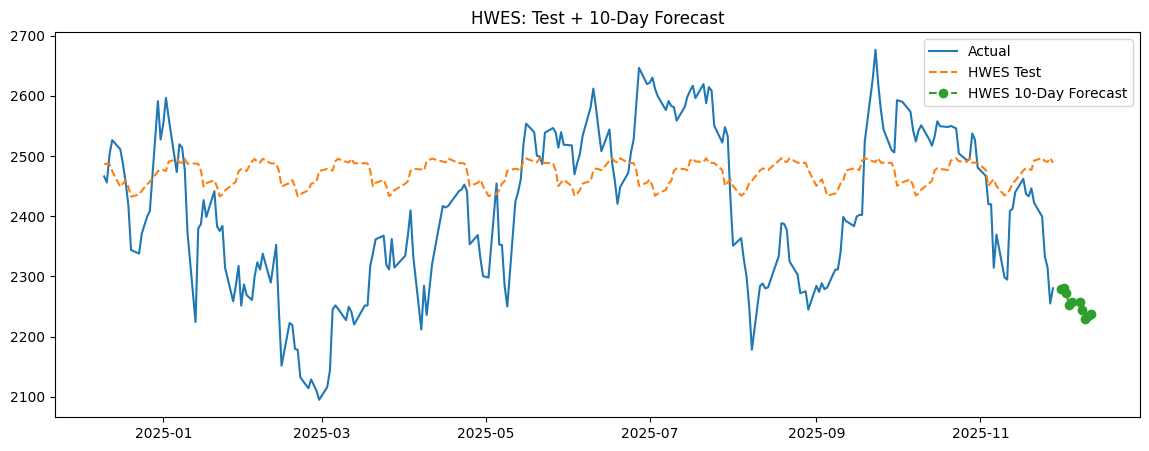

In [31]:

# Refit best HWES
trend, damped = best['trend'].split(", ")
hw_best = ExponentialSmoothing(
    train['Close'],
    trend,
    seasonal=best['seasonal'],
    seasonal_periods=best['order'] if best['seasonal'] else None,
    damped_trend=bool(damped)
).fit()
hw_pred = hw_best.forecast(len(test))

# Refit HWES on full data
hw_final = ExponentialSmoothing(
    df['Close'],
    trend, 
    seasonal=best['seasonal'],
    seasonal_periods=best['order'] if best['seasonal'] else None,
    damped_trend=bool(damped)
).fit()

future_steps = 10

hw_future  = hw_final.forecast(future_steps)

future_index = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq='B'
)

plt.figure(figsize=(14,5))

# Actual
plt.plot(test.index, test['Close'], label="Actual")

# Test predictions
plt.plot(test.index, hw_pred, '--', label="HWES Test")

# Future forecasts
plt.plot(future_index, hw_future, 'o--', label="HWES 10-Day Forecast")

plt.legend()
plt.title("HWES: Test + 10-Day Forecast")
plt.show()


In [38]:
final_results_df = pd.DataFrame(final_results)
print('Top Best Models:')
final_results_df[['model', 'rmse', 'mape']].sort_values(["rmse", "mape"]).reset_index(drop=True)


Top Best Models:


,model,rmse,mape
0,ARIMA,119.2493,0.0419
1,HWES,139.5485,0.0490
2,SES,149.6902,0.0524
3,SARIMA,187.0722,0.0623
4,MA,354.9422,0.1226
5,ARMA,354.9422,0.1226
6,AR,355.9067,0.1230
7,VAR,664.5271,0.2432
